### 使用一个额外ancilla的情形

In [25]:
import numpy as np
from TDD.TDD import TDD, Ini_TDD,Clear_TDD,set_index_order,get_unique_table_num,set_root_of_unit,get_count,cont,renormalize,Slicing2,Slicing,renormalize_wio_op
from TDD.TDD_Q import cir_2_tn,get_real_qubit_num,add_trace_line,add_inputs,add_outputs,gen_cir
from TDD.TN import Index,Tensor,TensorNetwork
from TDD.Syn import *
import time
import random
from qiskit import QuantumCircuit,qasm2, transpile
import cProfile
from IPython.display import display, HTML,Image
# from PIL import Image
from PIL import Image as PILImage
import networkx as nx
import copy
from qiskit.circuit.library.standard_gates import HGate,U1Gate,U3Gate
from qiskit.quantum_info.operators import Operator
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector
from qiskit.circuit import CircuitInstruction

import itertools

to_test = False

import warnings

warnings.simplefilter("ignore")

In [26]:
def oracle_syn2(tdd,n=0,cond={},data_q = -1,qa_used=False,n_r=0):

    if n==0:
        n = tdd.node.key+1
    cir = Circuit(n+2,[])
    qa = n
    data_q = n+1
    
    if tdd.node.key==-1:
        if abs(tdd.weight)<1e-10:
            cir = Circuit(n_r+2,[])
            return cir
        else:
            if qa_used:
                cir.data.append(Gate('x',{qa:1},data_q))
            else:
                cir.data.append(Gate('x',{},data_q))
        return cir
        
    u = tdd.node

    if u.successor[0]!=u.successor[1]:
        #把1分支关闭
        qa_used = True
        cond_n = copy.copy(cond)
        cond_n[u.key] = 1
        g = Gate('x',cond_n,qa)
        g.is_edge_op = True
        cir.data.append(g)

        bran_tdd = get_branch_dd(u,0)
        cir_end_t0 = oracle_syn2(bran_tdd,n,cond|{u.key:0},data_q,qa_used)
        cir.data=cir.data+cir_end_t0.data
    
        #把0分支关闭，1分支打开
        g=Gate('x',cond,qa)
        g.is_edge_op = True
        cir.data.append(g)

        reverse_q = []
        the_map = u.out_maps[1]
        while the_map.level>-1:
            q = the_map.level
            reverse_q.append(q)
            the_map=the_map.father
            
        bran_tdd = get_branch_dd(u,1)
        cir_end_t1 = oracle_syn2(bran_tdd,n,cond|{u.key:1},data_q,qa_used)
        for g in cir_end_t1.data:
            for k in g.q_c:
                if k in reverse_q:
                    g.q_c[k] = 1-g.q_c[k]        
        cir.data=cir.data+cir_end_t1.data

        #把0分支再打开
        cond_n = copy.copy(cond)
        cond_n[u.key] = 0
        g=Gate('x',cond_n,qa)
        g.is_edge_op = True
        cir.data.append(g)
    else:
        op_gates = []
        the_map = u.out_maps[1]
        while the_map.level>-1:
            q1 = u.key
            q = the_map.level
            g=Gate('x',{q1:1},q)
            g.is_edge_op = True
            op_gates.append(g)
            the_map=the_map.father
        cir.data+=op_gates
        bran_tdd = get_branch_dd(u,0)
        cir_end_t0 = oracle_syn2(bran_tdd,n,cond,data_q,qa_used)
        if abs(u.out_weight[1])<1e-10:
            cir_end_t0 = get_controlled_circuit2(cir_end_t0,{u.key:0},1,True)
        cir.data=cir.data+cir_end_t0.data
        op_gates.reverse()
        cir.data+=op_gates
            
    reverse_q = []
    the_map=tdd.map
    while the_map.level>-1:
        q = the_map.level
        reverse_q.append(q)
        the_map=the_map.father 
    for g in cir.data:
        for k in g.q_c:
            if k in reverse_q:
                g.q_c[k] = 1-g.q_c[k]
    return cir

def get_edge_op_cir(tdd):
    n = tdd.node.key+1
    cir = Circuit(n,[])

    the_map=tdd.map
    while the_map.level>-1:
        q = the_map.level
        cir.data.append(Gate('x',{},q))
        the_map=the_map.father 
        
    u = tdd.node
    if not u.has_op:
        return cir
        
    the_map = u.out_maps[1]
    while the_map.level>-1:
        q = the_map.level
        cir.data.append(Gate('x',{u.key:1},q))
        the_map=the_map.father
            
    bran_tdd = get_branch_dd(u,0)
    cir_end_t0 = get_edge_op_cir(bran_tdd)
    
    if tdd.node.successor[0]!=tdd.node.successor[1]:
        bran_tdd = get_branch_dd(u,1)
        cir_end_t1 = get_edge_op_cir(bran_tdd)
        cir_end_t0 = get_controlled_circuit2(cir_end_t0,{u.key:0},1,True)
        cir.data+=cir_end_t0.data
        cir_end_t1 = get_controlled_circuit2(cir_end_t1,{u.key:1},1,True)
        cir.data+=cir_end_t1.data
    else:
        if abs(u.out_weight[1])<1e-10:
            cir_end_t0 = get_controlled_circuit2(cir_end_t0,{u.key:0},1,True)
        cir.data+=cir_end_t0.data
    return cir

def opt_oracle_syn2(tdd,n=0,cond={},data_q = -1,qa_used=False,n_r=0):
    
        
    if tdd.node.key==-1 and abs(tdd.weight)<1e-10:
        cir = Circuit(n_r+2,[])
        return cir
        
    tdd_n = renormalize_wio_op(tdd.node)

    if not tdd_n.node_number()<tdd.node_number():
        cir2 = oracle_syn2(tdd,n,cond,data_q,qa_used,n_r)
        return cir2
    else:
        # print('aaa')
        n = tdd.node.key+1
        cir = Circuit(n+2,[])
        op_cir = get_edge_op_cir(tdd)
        op_cir = mcx_opt_pass(op_cir)
        cir.data+=op_cir.data
        cir2 = oracle_syn2(tdd_n,n,cond,data_q,qa_used,n_r)
        cir.data+=cir2.data
        op_cir.data.reverse()
        cir.data+=op_cir.data
        cir2 = oracle_syn2(tdd,n,cond,data_q,qa_used,n_r)
        if t_cost(cir)<t_cost(cir2):
            # print('bbb')
            return cir
        else:
            return cir2

def verify_success(cir,data,n):
    print(data)
    for k in range(2**n):
        input = format(k & ((1 << n) - 1), f'0{n}b')
        current_state = {n-1-q : int(input[q]) for q in range(n)}
        current_state[n] = 1
        current_state[n+1] = 0
        current_state_s = copy.copy(current_state)
        # print(current_state_s)
        for g in cir.data:
            flag = True
            for q in g.q_c:
                if g.q_c[q]!=current_state[q]:
                    flag = False
                    break
            if flag:
                current_state[g.q_t]=1-current_state[g.q_t]
        # print(current_state)
        
        for q in range(len(current_state)-1):
            if current_state[q]!=current_state_s[q]:
                print('Not Successful, see input:',input)
                break                
        if current_state[n+1]!=data[k]:
            print('Not Successful, see input:',input)
        # print('--')
    print('Successful')

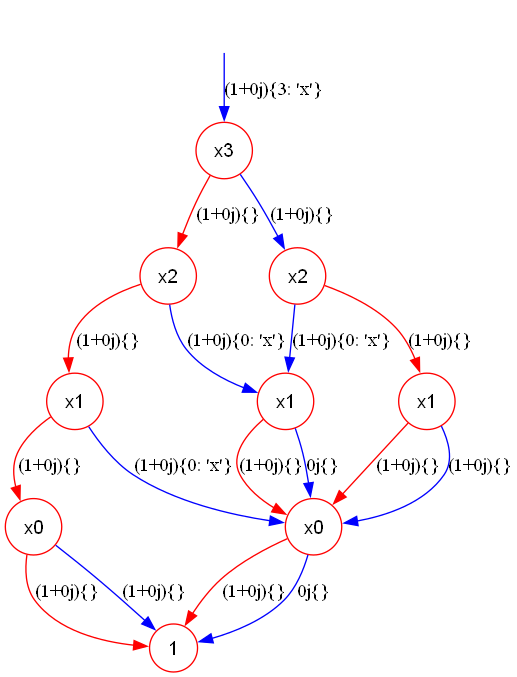

In [27]:
n=4
tdd,data = get_ramdom_TDD(n)
tdd.show()

# n = 3
# # vec = np.array([0,1,1,0,1,1,0,1])
# vec = np.array([1,0,0,0,0,0,0,0]) 
# data = vector_to_tensor(vec,n)
# var_order_s = ['x2','x1','x0']
# # var_order_s = ['x0','x1','x2']
# tdd,data = get_ramdom_TDD(n,data,var_order_s)
# # tdd.map=tdd.map.append_new_map(2,1,0)
# # data = np.array([0,1,1,0,1,1,0,1])
# # tdd,data = get_TDD_from_truth_table(n,223)
tdd.show()

In [28]:
t_start = time.time()
cir = oracle_syn2(tdd,n_r=n)
print(time.time()-t_start)
verify_success(cir,data,n)
print(cir)

0.002441883087158203
[1 0 1 0 0 1 0 0 1 1 0 1 0 1 0 0]
Successful
[('x', '(3: 0)', 4, array([[0, 1],
       [1, 0]])),('x', '(3: 1, 2: 1)', 4, array([[0, 1],
       [1, 0]])),('x', '(3: 1, 2: 0, 1: 1)', 4, array([[0, 1],
       [1, 0]])),('x', '(4: 1)', 5, array([[0, 1],
       [1, 0]])),('x', '(3: 1, 2: 0)', 4, array([[0, 1],
       [1, 0]])),('x', '(4: 1, 0: 1)', 5, array([[0, 1],
       [1, 0]])),('x', '(3: 1, 2: 0, 1: 0)', 4, array([[0, 1],
       [1, 0]])),('x', '(3: 1)', 4, array([[0, 1],
       [1, 0]])),('x', '(4: 1, 0: 1, 1: 0)', 5, array([[0, 1],
       [1, 0]])),('x', '(3: 1, 2: 0)', 4, array([[0, 1],
       [1, 0]])),('x', '()', 4, array([[0, 1],
       [1, 0]])),('x', '(3: 0, 2: 1)', 4, array([[0, 1],
       [1, 0]])),('x', '(4: 1, 0: 0)', 5, array([[0, 1],
       [1, 0]])),('x', '(3: 0)', 4, array([[0, 1],
       [1, 0]])),('x', '(4: 1, 0: 1, 1: 0)', 5, array([[0, 1],
       [1, 0]])),('x', '(3: 0, 2: 0)', 4, array([[0, 1],
       [1, 0]])),('x', '(3: 1)', 4, array([[0, 1

0.02539515495300293


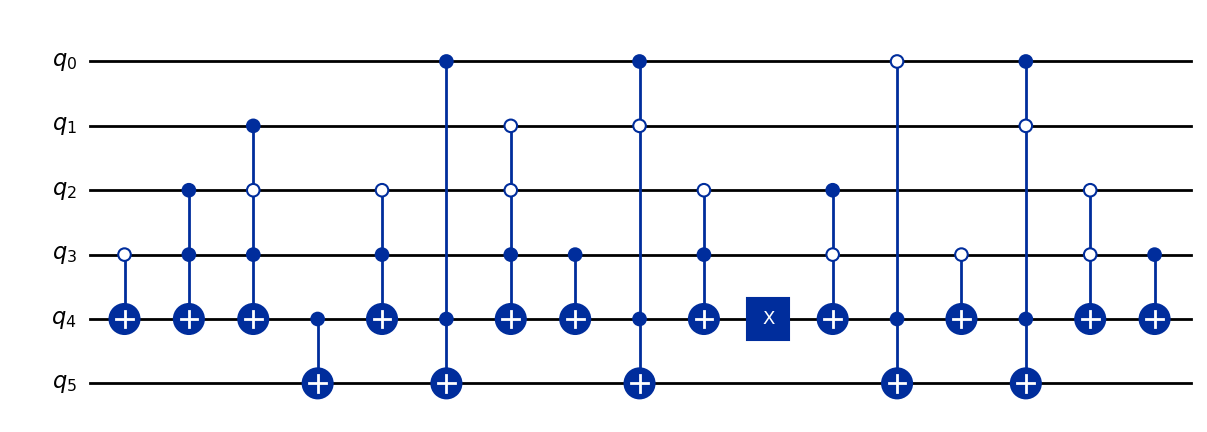

In [29]:
t_start = time.time()
cir_qis = cir.to_qis_cir()
print(time.time()-t_start)
cir_qis.draw('mpl')

0.0010485649108886719
[1 0 1 0 0 1 0 0 1 1 0 1 0 1 0 0]
Successful
[('x', '(3: 0)', 4, array([[0, 1],
       [1, 0]])),('x', '(3: 1, 2: 1)', 4, array([[0, 1],
       [1, 0]])),('x', '(3: 1, 2: 0, 1: 1)', 4, array([[0, 1],
       [1, 0]])),('x', '(4: 1)', 5, array([[0, 1],
       [1, 0]])),('x', '(3: 1, 2: 0)', 4, array([[0, 1],
       [1, 0]])),('x', '(4: 1, 0: 1)', 5, array([[0, 1],
       [1, 0]])),('x', '(3: 1, 2: 0, 1: 0)', 4, array([[0, 1],
       [1, 0]])),('x', '(3: 1)', 4, array([[0, 1],
       [1, 0]])),('x', '(4: 1, 0: 1, 1: 0)', 5, array([[0, 1],
       [1, 0]])),('x', '(3: 1, 2: 0)', 4, array([[0, 1],
       [1, 0]])),('x', '()', 4, array([[0, 1],
       [1, 0]])),('x', '(3: 0, 2: 1)', 4, array([[0, 1],
       [1, 0]])),('x', '(4: 1, 0: 0)', 5, array([[0, 1],
       [1, 0]])),('x', '(3: 0)', 4, array([[0, 1],
       [1, 0]])),('x', '(4: 1, 0: 1, 1: 0)', 5, array([[0, 1],
       [1, 0]])),('x', '(3: 0, 2: 0)', 4, array([[0, 1],
       [1, 0]])),('x', '(3: 1)', 4, array([[0, 

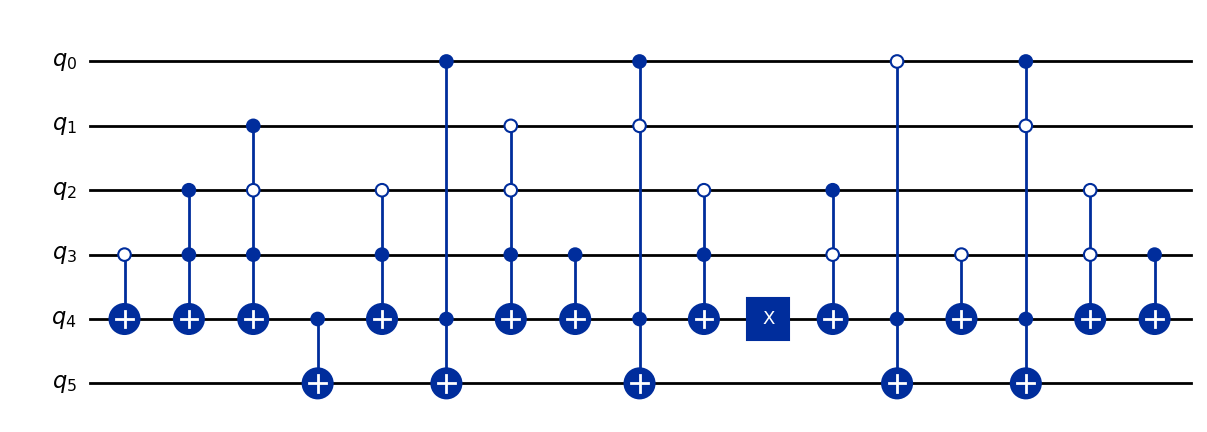

In [30]:
t_start = time.time()
cir = opt_oracle_syn2(tdd,n_r=n)
print(time.time()-t_start)
verify_success(cir,data,n)
print(cir)
cir_qis = cir.to_qis_cir()
cir_qis.draw('mpl')